<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/CNN_Flower_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. Yêu cầu: Mô hình CNN

# MÔ HÌNH XÂY DỰNG

Input: 128 × 128 × 3

→ Conv2D (32 filters, 3×3) + ReLU
→ MaxPooling2D (2×2)

→ Conv2D (64 filters, 3×3) + ReLU
→ MaxPooling2D (2×2)

→ Flatten
→ Dense (128) + ReLU
→ Dense (5) + Softmax

- Conv2D: trích xuất đặc trưng (edges, textures, shapes)
- MaxPooling2D: giảm chiều dữ liệu, giữ đặc trưng quan trọng
- Flatten: chuyển tensor 2D → vector 1D
- Dense: học quan hệ phi tuyến để phân loại

# 1. IMPORT LIBRARIES

In [1]:
# ======================================================
# 1. IMPORT LIBRARIES
# ======================================================

# ==============================
# 1.1 SYSTEM & DATA PROCESSING
# ==============================

import os
import random

import numpy as np
import pandas as pd

# ==============================
# 1.2 IMAGE PROCESSING
# ==============================

import cv2

# ==============================
# 1.3 DATA VISUALIZATION
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1.4 DEEP LEARNING (TensorFlow / Keras)
# ==============================

import tensorflow as tf

from tensorflow.keras import layers, models

from tensorflow.keras.models import Model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ==============================
# 1.5 EVALUATION METRICS
# ==============================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score
)

# ==============================
# 1.6 LABEL PROCESSING
# ==============================

from sklearn.preprocessing import label_binarize

print("Thư viện đã được import .")

Thư viện đã được import .


# **2. THIẾT LẬP HYPERPARAMETERS** CHO CNN

-  Resize ảnh về kích thước 128×128 để đồng nhất dữ liệu đầu vào.

-  BATCH_SIZE = 32 và EPOCHS = 40 cho quá trình huấn luyện mô hình.
-  LEARNING_RATE = 0.0001 để tối ưu quá trình cập nhật trọng số.
-  SEED = 42 nhằm đảm bảo khả năng tái lập kết quả.

-  Kiểm tra phiên bản TensorFlow và NumPy để xác nhận môi trường thực thi.

In [2]:
# ======================================================
# 2. HYPERPARAMETERS CONFIGURATION
# ======================================================

# ==============================
# 2.1 IMAGE SIZE
# ==============================
# Resize toàn bộ ảnh về cùng kích thước

IMG_SIZE = (128, 128)

# ==============================
# 2.2 BATCH SIZE
# ==============================
# Số lượng ảnh trong mỗi batch

BATCH_SIZE = 32

# ==============================
# 2.3 NUMBER OF EPOCHS
# ==============================
# Số vòng huấn luyện tối đa

EPOCHS = 40

# ==============================
# 2.4 LEARNING RATE
# ==============================
# Tốc độ cập nhật trọng số

LEARNING_RATE = 0.0001

# ==============================
# 2.5 RANDOM SEED
# ==============================
# Đảm bảo khả năng tái lập kết quả

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==============================
# 2.6 DISPLAY INFORMATION
# ==============================

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

print("\nEnvironment Setup Completed Successfully!")

TensorFlow Version: 2.20.0
NumPy Version: 2.0.2

Environment Setup Completed Successfully!


# **3. DATA ACQUISITION** - THU THẬP DỮ LIỆU
- Cài đặt và cấu hình Kaggle API để tải dataset trực tiếp trên Google Colab.

- Tải dataset “Flowers Recognition” từ Kaggle và giải nén vào thư mục làm việc.
- Xác định đường dẫn dữ liệu và kiểm tra các lớp ảnh trong dataset.
- Thống kê số lượng ảnh của từng lớp nhằm đánh giá phân bố dữ liệu.
- Hiển thị tổng số ảnh và thông tin dataset để phục vụ quá trình huấn luyện mô hình CNN.

In [3]:
# ======================================================
# 3. DATA ACQUISITION
# ======================================================

# ==============================
# 3.1 INSTALL KAGGLE API
# ==============================

!pip install -q kaggle

# ==============================
# 3.2 UPLOAD KAGGLE API KEY
# ==============================

from google.colab import files

files.upload()   # Upload kaggle.json

# ==============================
# 3.3 CREATE KAGGLE DIRECTORY
# ==============================

os.makedirs("/root/.kaggle", exist_ok=True)

# Copy kaggle.json into Kaggle folder
!cp kaggle.json /root/.kaggle/

# Set permission
!chmod 600 /root/.kaggle/kaggle.json

# ==============================
# 3.4 DOWNLOAD DATASET
# ==============================

!kaggle datasets download -d alxmamaev/flowers-recognition

# ==============================
# 3.5 EXTRACT DATASET
# ==============================

!unzip -q flowers-recognition.zip -d /content/

# ==============================
# 3.6 DEFINE DATASET PATH
# ==============================

base_dir = "/content/flowers"

print("Dataset Path:", base_dir)



Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:01<00:00, 219MB/s]

Dataset Path: /content/flowers


In [4]:
# ==============================
# 3.7 CHECK CLASS NAMES
# ==============================

class_names = os.listdir(base_dir)

print("\nClasses in Dataset:")

for class_name in class_names:
    print("-", class_name)

# ==============================
# 3.8 COUNT IMAGES PER CLASS
# ==============================

class_counts = {}

for class_name in class_names:

    class_path = os.path.join(base_dir, class_name)

    num_images = len(os.listdir(class_path))

    class_counts[class_name] = num_images

# ==============================
# 3.9 DISPLAY DATASET SUMMARY
# ==============================

print("\nNumber of Images per Class:\n")

total_images = 0

for class_name, count in class_counts.items():

    print(f"{class_name}: {count} images")

    total_images += count

print("\nTotal Images:", total_images)


Classes in Dataset:
- daisy
- rose
- sunflower
- dandelion
- tulip

Number of Images per Class:

daisy: 764 images
rose: 784 images
sunflower: 733 images
dandelion: 1052 images
tulip: 984 images

Total Images: 4317


In [ ]:
# ======================================================
# 3. DATA ACQUISITION
# ======================================================

# ==============================
# 3.1 INSTALL KAGGLE API
# ==============================

!pip install -q kaggle

# ==============================
# 3.2 UPLOAD KAGGLE API KEY
# ==============================

from google.colab import files

files.upload()   # Upload kaggle.json

# ==============================
# 3.3 CREATE KAGGLE DIRECTORY
# ==============================

os.makedirs("/root/.kaggle", exist_ok=True)

# Copy kaggle.json into Kaggle folder
!cp kaggle.json /root/.kaggle/

# Set permission
!chmod 600 /root/.kaggle/kaggle.json

# ==============================
# 3.4 DOWNLOAD DATASET
# ==============================

!kaggle datasets download -d alxmamaev/flowers-recognition

# ==============================
# 3.5 EXTRACT DATASET
# ==============================

!unzip -q flowers-recognition.zip -d /content/

# ==============================
# 3.6 DEFINE DATASET PATH
# ==============================

base_dir = "/content/flowers"

print("Dataset Path:", base_dir)

# ==============================
# 3.7 CHECK CLASS NAMES
# ==============================

class_names = os.listdir(base_dir)

print("\nClasses in Dataset:")

for class_name in class_names:
    print("-", class_name)

# ==============================
# 3.8 COUNT IMAGES PER CLASS
# ==============================

class_counts = {}

for class_name in class_names:

    class_path = os.path.join(base_dir, class_name)

    num_images = len(os.listdir(class_path))

    class_counts[class_name] = num_images

# ==============================
# 3.9 DISPLAY DATASET SUMMARY
# ==============================

print("\nNumber of Images per Class:\n")

total_images = 0

for class_name, count in class_counts.items():

    print(f"{class_name}: {count} images")

    total_images += count

print("\nTotal Images:", total_images)

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:01<00:00, 120MB/s]

Dataset Path: /content/flowers

Classes in Dataset:
- daisy
- rose
- sunflower
- dandelion
- tulip

Number of Images per Class:

daisy: 764 images
rose: 784 images
sunflower: 733 images
dandelion: 1052 images
tulip: 984 images

Total Images: 4317


# NHẬN XÉT VỀ DỮ LIỆU
- Có tổng cộng 4317 bức ảnh
- Gồm 5 loại ảnh : daisy, rose, sunflower, dandelion, tulip


#**# 4. DATA PREPROCESSING & EXPLORATORY ANALYSIS**

- Thực hiện khảo sát dữ liệu (Exploratory Data Analysis) để kiểm tra số lượng ảnh và phân bố dữ liệu của từng lớp hoa.
- Trực quan hóa dữ liệu bằng biểu đồ phân bố lớp và hiển thị ảnh mẫu của từng loại hoa.
- Áp dụng tiền xử lý dữ liệu gồm chuẩn hóa giá trị pixel về khoảng [0,1] và resize ảnh về cùng kích thước.
- Sử dụng kỹ thuật Data Augmentation như xoay ảnh, phóng to, tịnh tiến và lật ảnh để tăng tính đa dạng dữ liệu huấn luyện và giảm overfitting.
- Chia dữ liệu thành tập huấn luyện (80%) và tập validation (20%) bằng ImageDataGenerator.
- Kiểm tra thông tin dữ liệu đầu vào như số lớp, kích thước batch ảnh và phạm vi giá trị pixel sau chuẩn hóa.

In [5]:
# ======================================================
# 4. DATA PREPROCESSING & EXPLORATORY ANALYSIS
# ======================================================

# ==============================
# 4.1 DATASET OVERVIEW
# ==============================

print("Dataset Overview\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

Dataset Overview

daisy: 764 images
rose: 784 images
sunflower: 733 images
dandelion: 1052 images
tulip: 984 images


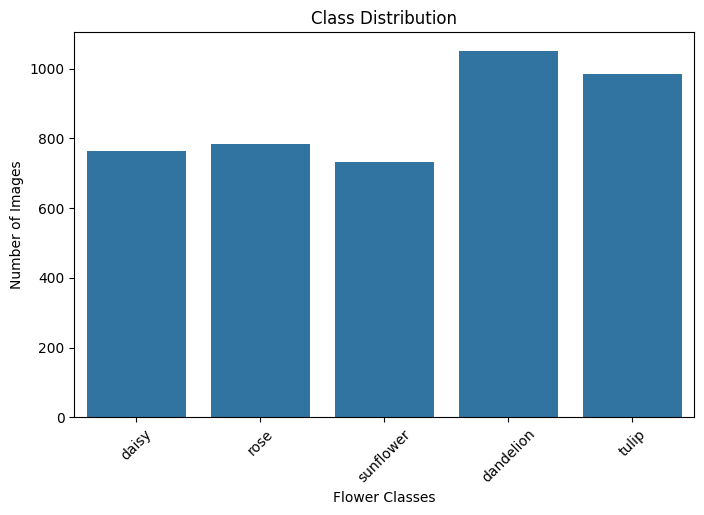

In [6]:
# ==============================
# 4.2 CLASS DISTRIBUTION
# ==============================

df_classes = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_classes,
    x="Class",
    y="Count"
)

plt.title("Class Distribution")
plt.xlabel("Flower Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

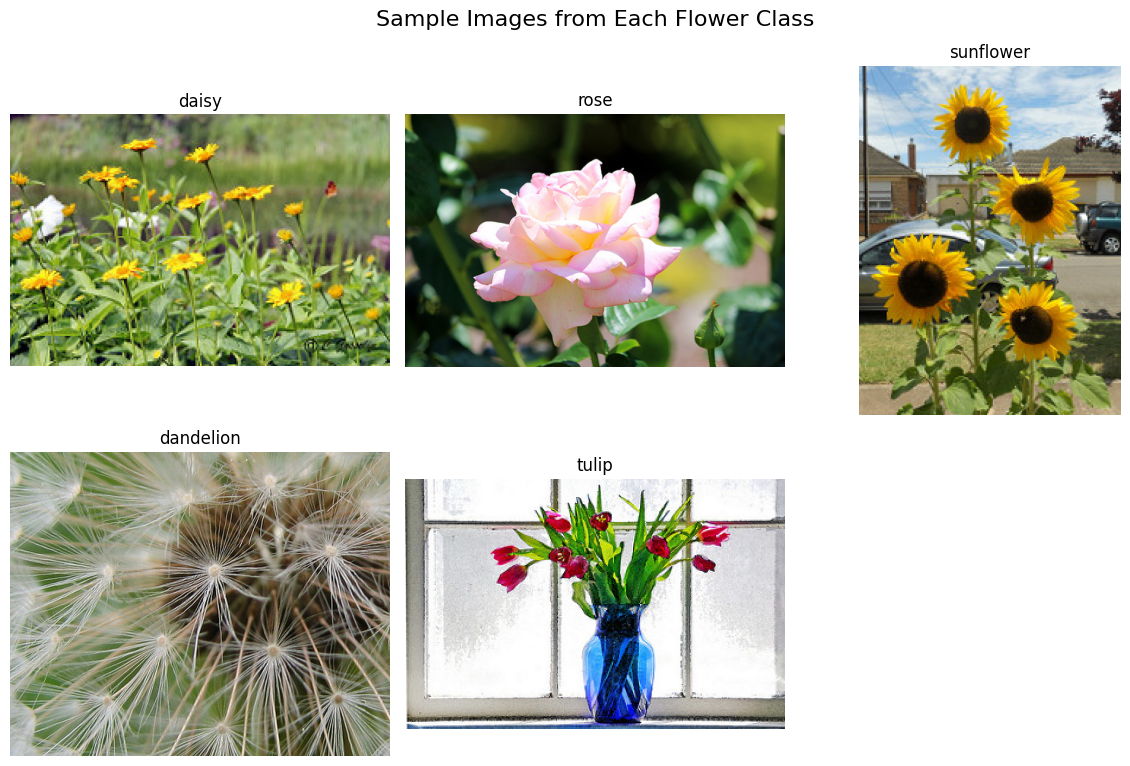

In [7]:
# ==============================
# 4.3 VISUALIZE SAMPLE IMAGES
# ==============================

plt.figure(figsize=(12,8))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(base_dir, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    # Read image
    image = cv2.imread(image_path)

    # Convert BGR -> RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display image
    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.suptitle("Sample Images from Each Flower Class", fontsize=16)

plt.tight_layout()

plt.show()

In [8]:
# ==============================
# 4.4 DATA AUGMENTATION
# ==============================

# Training Data Generator
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=30,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2
)

# Validation Data Generator
# Validation data should NOT use augmentation

val_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2
)
print("Cấu hình tăng cường dữ liệu và chuẩn hóa dữ liệu đã được thiết lập thành công!")

print("\nTraining Augmentation:")
print("- Rescale = 1./255")
print("- Rotation Range = 30")
print("- Width Shift Range = 0.1")
print("- Height Shift Range = 0.1")
print("- Zoom Range = 0.2")
print("- Horizontal Flip = True")

print("\nValidation Data:")
print("- Only Rescaling Applied")

Cấu hình tăng cường dữ liệu và chuẩn hóa dữ liệu đã được thiết lập thành công!

Training Augmentation:
- Rescale = 1./255
- Rotation Range = 30
- Width Shift Range = 0.1
- Height Shift Range = 0.1
- Zoom Range = 0.2
- Horizontal Flip = True

Validation Data:
- Only Rescaling Applied


In [9]:
# ==============================
# 4.5 TRAINING GENERATOR
# ==============================

train_data = train_datagen.flow_from_directory(

    base_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True,

    seed=SEED
)
print("Training data generator đã được tạo thành công!")

print("\nTraining Dataset Information:")
print("Tổng số  training samples:", train_data.samples)
print("Batch size:", train_data.batch_size)
print("Image size:", IMG_SIZE)
print("Tổng số classes:", train_data.num_classes)

Found 3457 images belonging to 5 classes.
Training data generator đã được tạo thành công!

Training Dataset Information:
Tổng số  training samples: 3457
Batch size: 32
Image size: (128, 128)
Tổng số classes: 5


In [10]:
# ==============================
# 4.6 VALIDATION GENERATOR
# ==============================

val_data = val_datagen.flow_from_directory(

    base_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

print("Tập Validation đã được tạo thành công !")

print("\nValidation Dataset Information:")
print("Number of validation samples:", val_data.samples)
print("Batch size:", val_data.batch_size)
print("Image size:", IMG_SIZE)

Found 860 images belonging to 5 classes.
Tập Validation đã được tạo thành công !

Validation Dataset Information:
Number of validation samples: 860
Batch size: 32
Image size: (128, 128)


In [11]:
# ==============================
# 4.7 CLASS INFORMATION
# ==============================

class_names = list(train_data.class_indices.keys())

num_classes = len(class_names)

print("\nClass Names:")

for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("\nNumber of Classes:", num_classes)



Class Names:
0: daisy
1: dandelion
2: rose
3: sunflower
4: tulip

Number of Classes: 5


Hiển thị các ảnh huấn luyện sau khi tăng cường dữ liệu


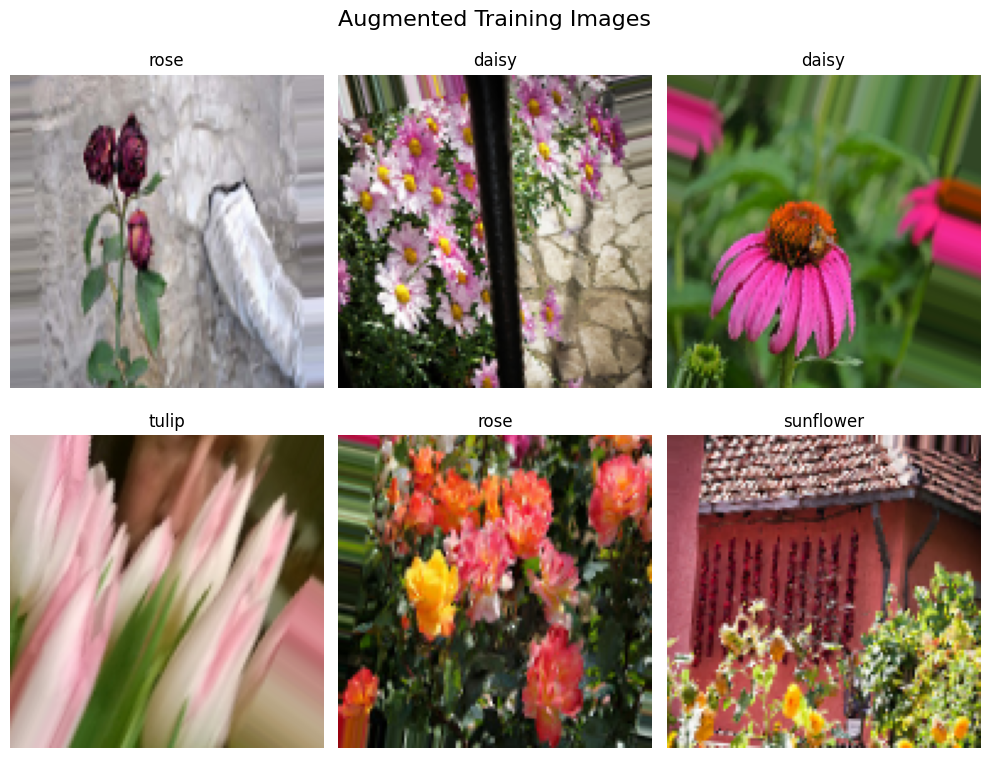

In [12]:
# ==============================
# 4.8 VISUALIZE AUGMENTED IMAGES
# ==============================

images, labels = next(train_data)

plt.figure(figsize=(10,8))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.suptitle("Augmented Training Images", fontsize=16)

plt.tight_layout()
print("Hiển thị các ảnh huấn luyện sau khi tăng cường dữ liệu")

plt.show()

In [13]:

# ==============================
# 4.9 CHECK DATA SHAPE
# ==============================

print("Data Shape Information\n")

print("\nImage Batch Shape:", images.shape)

print("Label Batch Shape:", labels.shape)

Data Shape Information


Image Batch Shape: (32, 128, 128, 3)
Label Batch Shape: (32, 5)


In [14]:
# ==============================
# 4.10 VERIFY NORMALIZATION
# ==============================

print("\nPixel Value Range:")
print("Kiểm tra chuẩn hóa dữ liệu \n")

print("Minimum Pixel Value:", images.min())

print("Maximum Pixel Value:", images.max())


Pixel Value Range:
Kiểm tra chuẩn hóa dữ liệu 

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


Dataset Overview

daisy: 764 images
rose: 784 images
sunflower: 733 images
dandelion: 1052 images
tulip: 984 images


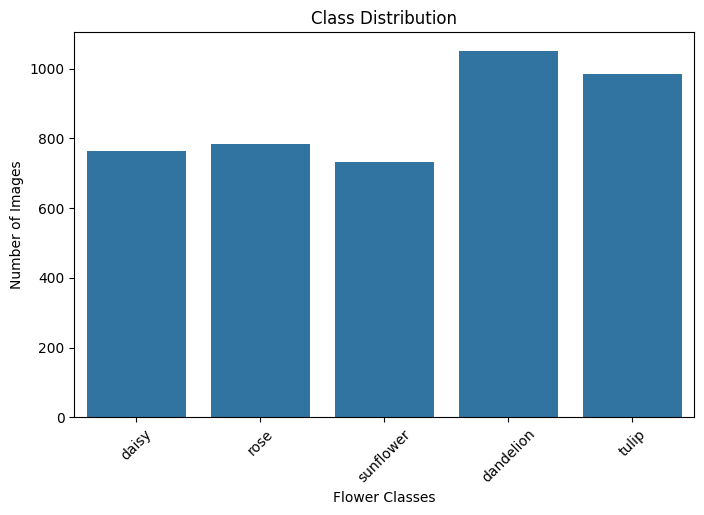

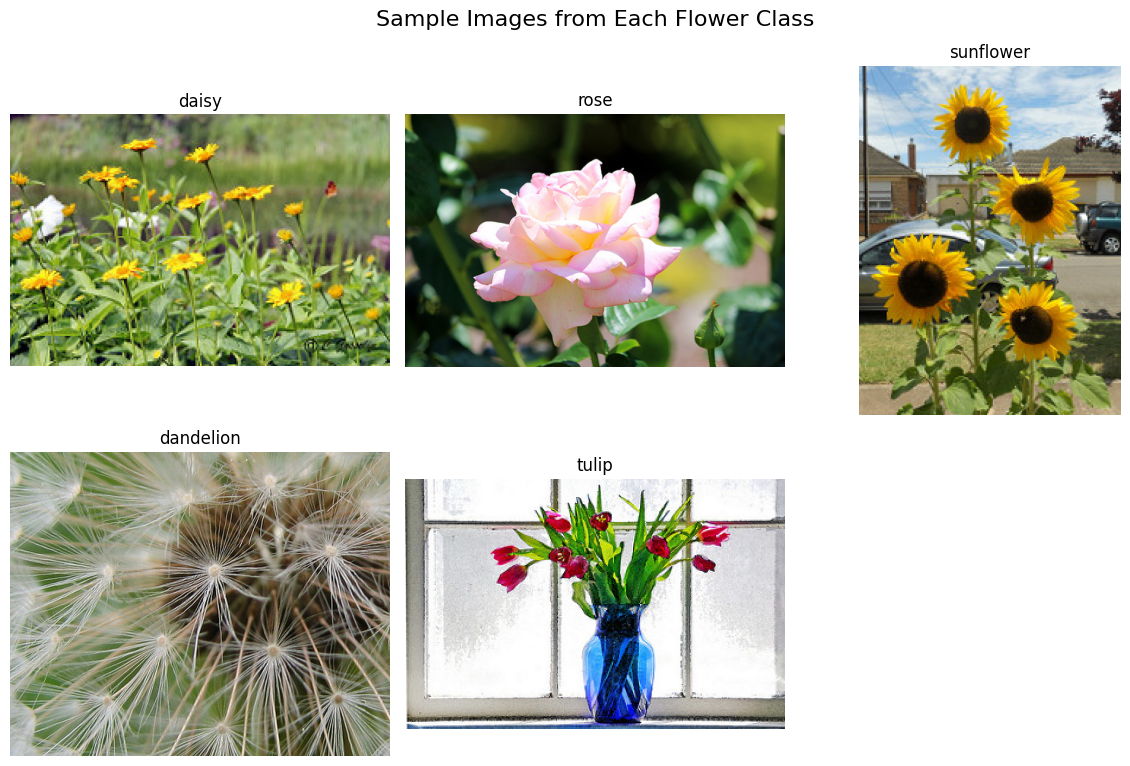

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.

Class Names:
0: daisy
1: dandelion
2: rose
3: sunflower
4: tulip

Number of Classes: 5


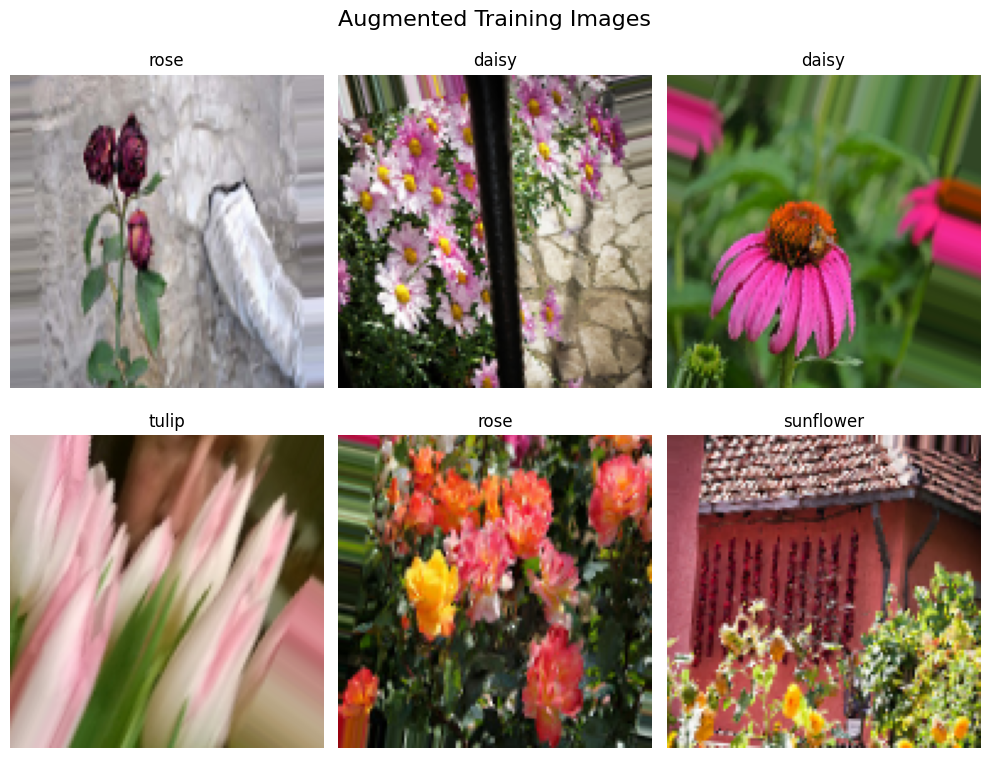


Image Batch Shape: (32, 128, 128, 3)
Label Batch Shape: (32, 5)

Pixel Value Range:
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [ ]:
# ======================================================
# 4. DATA PREPROCESSING & EXPLORATORY ANALYSIS
# ======================================================

# ==============================
# 4.1 DATASET OVERVIEW
# ==============================

print("Dataset Overview\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

# ==============================
# 4.2 CLASS DISTRIBUTION
# ==============================

df_classes = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_classes,
    x="Class",
    y="Count"
)

plt.title("Class Distribution")
plt.xlabel("Flower Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

# ==============================
# 4.3 VISUALIZE SAMPLE IMAGES
# ==============================

plt.figure(figsize=(12,8))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(base_dir, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    # Read image
    image = cv2.imread(image_path)

    # Convert BGR -> RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display image
    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.suptitle("Sample Images from Each Flower Class", fontsize=16)

plt.tight_layout()

plt.show()

# ==============================
# 4.4 DATA AUGMENTATION
# ==============================

# Training Data Generator
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=30,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2
)

# Validation Data Generator
# Validation data should NOT use augmentation

val_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2
)

# ==============================
# 4.5 TRAINING GENERATOR
# ==============================

train_data = train_datagen.flow_from_directory(

    base_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True,

    seed=SEED
)

# ==============================
# 4.6 VALIDATION GENERATOR
# ==============================

val_data = val_datagen.flow_from_directory(

    base_dir,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

# ==============================
# 4.7 CLASS INFORMATION
# ==============================

class_names = list(train_data.class_indices.keys())

num_classes = len(class_names)

print("\nClass Names:")

for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("\nNumber of Classes:", num_classes)

# ==============================
# 4.8 VISUALIZE AUGMENTED IMAGES
# ==============================

images, labels = next(train_data)

plt.figure(figsize=(10,8))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.suptitle("Augmented Training Images", fontsize=16)

plt.tight_layout()

plt.show()

# ==============================
# 4.9 CHECK DATA SHAPE
# ==============================

print("\nImage Batch Shape:", images.shape)

print("Label Batch Shape:", labels.shape)

# ==============================
# 4.10 VERIFY NORMALIZATION
# ==============================

print("\nPixel Value Range:")

print("Minimum Pixel Value:", images.min())

print("Maximum Pixel Value:", images.max())

# 5. CNN MODEL BUILDING

In [ ]:
# ======================================================
# 5. CNN MODEL BUILDING
# ======================================================

# ==============================
# 5.1 BUILD CNN MODEL
# ==============================

model = models.Sequential([

    # ==================================================
    # INPUT LAYER
    # ==================================================

    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    # ==================================================
    # CONVOLUTION BLOCK 1
    # ==================================================

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    # ==================================================
    # CONVOLUTION BLOCK 2
    # ==================================================

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    # ==================================================
    # CONVOLUTION BLOCK 3
    # ==================================================

    layers.Conv2D(
        filters=128,
        kernel_size=(3,3),
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    # ==================================================
    # FLATTEN LAYER
    # ==================================================

    layers.Flatten(),

    # ==================================================
    # FULLY CONNECTED LAYER
    # ==================================================

    layers.Dense(
        128,
        activation='relu'
    ),

    # ==================================================
    # DROPOUT LAYER
    # ==================================================

    layers.Dropout(0.3),

    # ==================================================
    # OUTPUT LAYER
    # ==================================================

    layers.Dense(
        num_classes,
        activation='softmax'
    )

])

# ==============================
# 5.2 COMPILE MODEL
# ==============================

optimizer = Adam(
    learning_rate=LEARNING_RATE
)

model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# ==============================
# 5.3 MODEL SUMMARY
# ==============================

print("\nCNN Model Architecture Summary\n")

model.summary()


CNN Model Architecture Summary



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,221 (16.36 MB)

 Trainable params: 4,288,773 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

# 6. MODEL TRAINING

In [ ]:
# ======================================================
# 6. MODEL TRAINING
# ======================================================

# ==============================
# 6.1 EARLY STOPPING
# ==============================
# Dừng huấn luyện nếu validation loss
# không còn cải thiện

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True,

    verbose=1
)

# ==============================
# 6.2 REDUCE LEARNING RATE
# ==============================
# Giảm learning rate khi validation loss
# không cải thiện

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.3,

    patience=3,

    min_lr=1e-6,

    verbose=1
)

# ==============================
# 6.3 MODEL CHECKPOINT
# ==============================
# Lưu mô hình tốt nhất

checkpoint = ModelCheckpoint(

    filepath='best_cnn_model.keras',

    monitor='val_loss',

    save_best_only=True,

    verbose=1
)

# ==============================
# 6.4 TRAIN CNN MODEL
# ==============================

history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=EPOCHS,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint
    ]
)

# ==============================
# 6.5 SAVE FINAL MODEL
# ==============================

model.save("final_cnn_model.keras")

print("\nModel training completed successfully!")

# ==============================
# 6.6 LOAD BEST MODEL (OPTIONAL)
# ==============================

best_model = tf.keras.models.load_model(
    "best_cnn_model.keras"
)

print("\nBest model loaded successfully!")

Epoch 1/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4027 - loss: 1.8697
Epoch 1: val_loss improved from None to 2.36757, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
109/109 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.4672 - loss: 1.4736 - val_accuracy: 0.2291 - val_loss: 2.3676 - learning_rate: 1.0000e-04
Epoch 2/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5150 - loss: 1.1962
Epoch 2: val_loss did not improve from 2.36757
109/109 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.5230 - loss: 1.1807 - val_accuracy: 0.3314 - val_loss: 3.3277 - learning_rate: 1.0000e-04
Epoch 3/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5567 - loss: 1.1026
Epoch 3: val_loss did not improve from 2.36757
109/109 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.5548 - loss: 1.0869 - val_accuracy: 0.3302 - val_loss: 4.4457 - learning_rate: 1.0000e-04
Epoch 4/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5778 -

# 7. MODEL EVALUATION & PERFORMANCE ANALYSIS

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 455ms/step


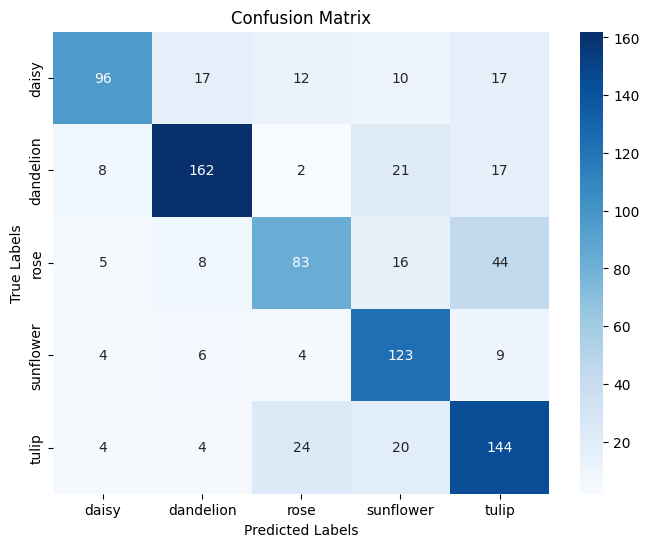


Classification Report

              precision    recall  f1-score   support

       daisy       0.82      0.63      0.71       152
   dandelion       0.82      0.77      0.80       210
        rose       0.66      0.53      0.59       156
   sunflower       0.65      0.84      0.73       146
       tulip       0.62      0.73      0.67       196

    accuracy                           0.71       860
   macro avg       0.72      0.70      0.70       860
weighted avg       0.72      0.71      0.71       860


Overall Performance Metrics

Accuracy  : 0.7070
Precision : 0.7182
Recall    : 0.7070
F1-Score  : 0.7057


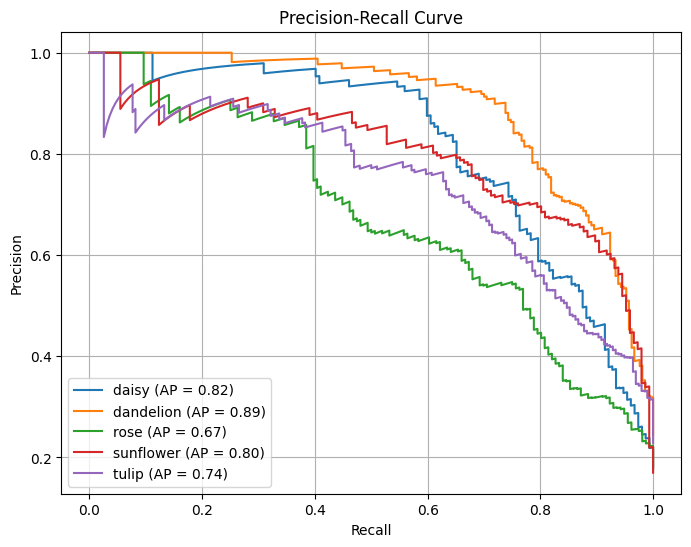

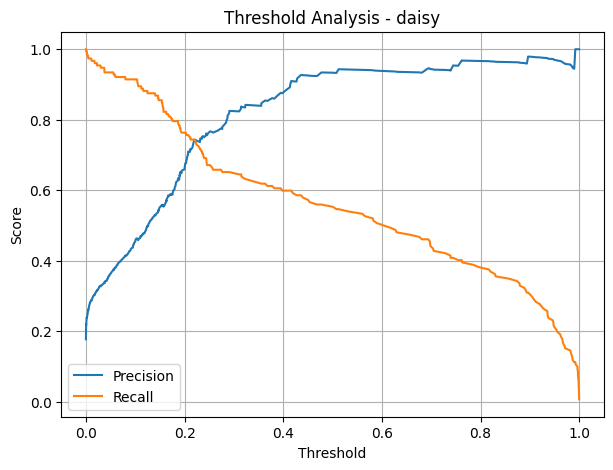

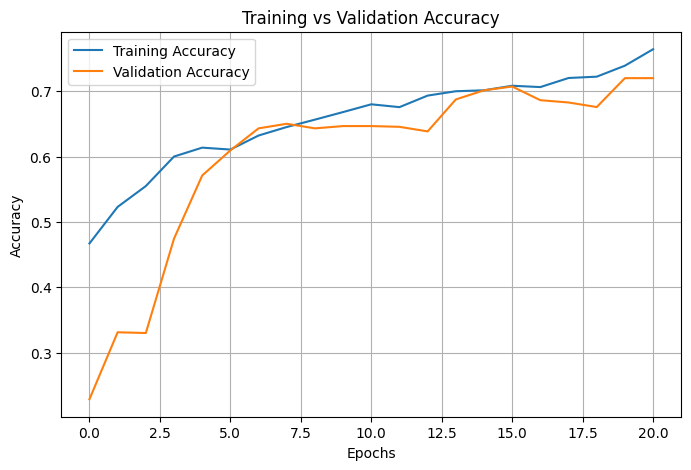

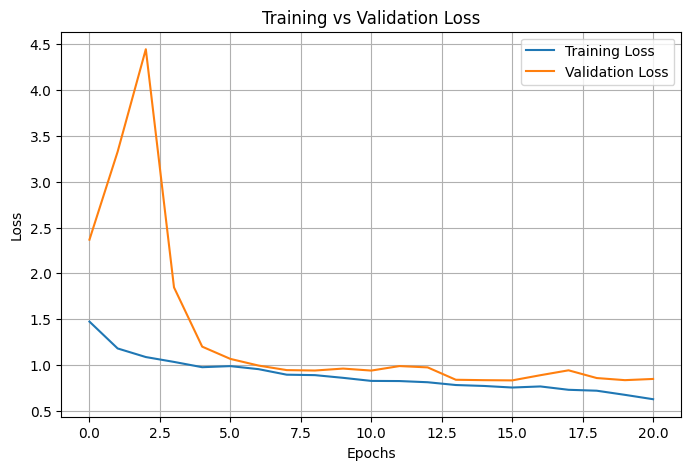


Total Misclassified Images:
252


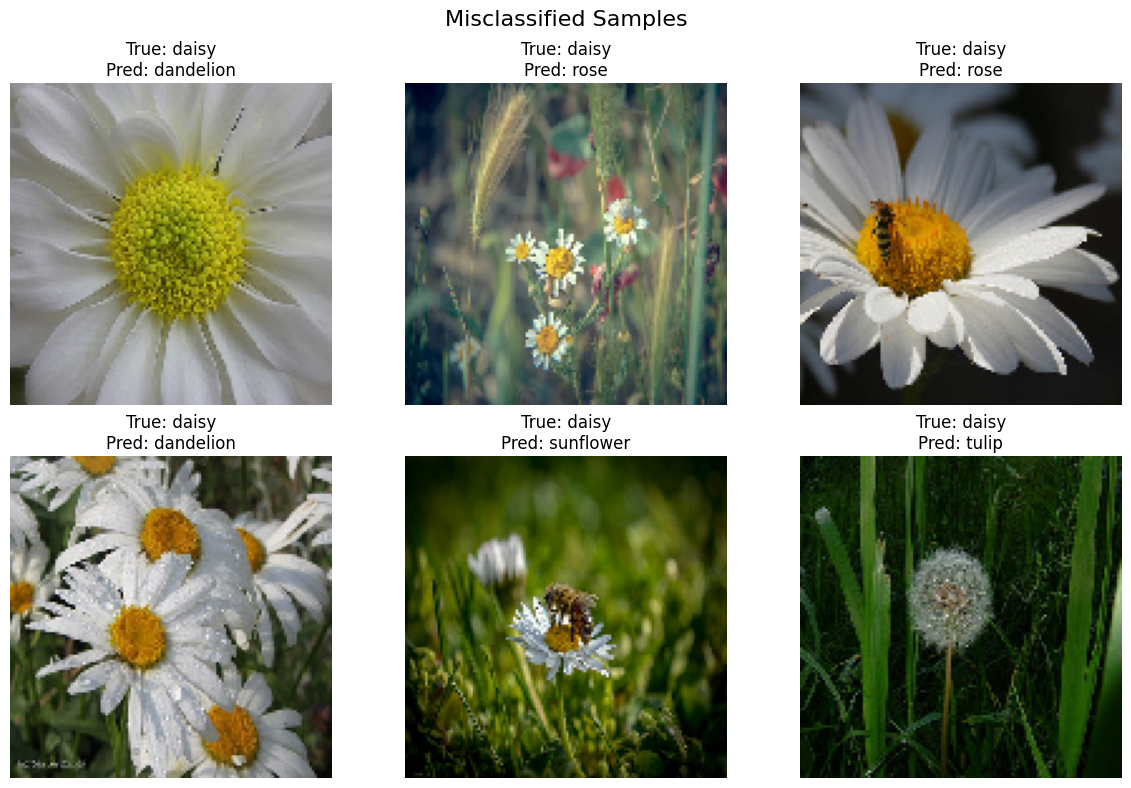


Classification report saved successfully!


In [ ]:
# ======================================================
# 7. MODEL EVALUATION & PERFORMANCE ANALYSIS
# ======================================================

# ==============================
# 7.1 PREDICT VALIDATION DATA
# ==============================

# Predict probabilities
y_prob = model.predict(val_data)

# Convert probabilities -> predicted labels
y_pred = np.argmax(y_prob, axis=1)

# True labels
y_true = val_data.classes

# Class names
class_names = list(val_data.class_indices.keys())

# ==============================
# 7.2 CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.show()

# ==============================
# 7.3 CLASSIFICATION REPORT
# ==============================

print("\nClassification Report\n")

print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names
    )
)

# ==============================
# 7.4 OVERALL METRICS
# ==============================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\nOverall Performance Metrics\n")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

# ==============================
# 7.5 PRECISION-RECALL CURVE
# ==============================

# Convert labels to binary format
y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    precision_curve, recall_curve, _ = precision_recall_curve(

        y_true_bin[:, i],

        y_prob[:, i]
    )

    ap_score = average_precision_score(

        y_true_bin[:, i],

        y_prob[:, i]
    )

    plt.plot(

        recall_curve,

        precision_curve,

        label=f"{class_names[i]} (AP = {ap_score:.2f})"
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

# ==============================
# 7.6 THRESHOLD ANALYSIS
# ==============================

# Example: analyze class 0
target_class = 0

precision_curve, recall_curve, thresholds = precision_recall_curve(

    y_true_bin[:, target_class],

    y_prob[:, target_class]
)

plt.figure(figsize=(7,5))

plt.plot(

    thresholds,

    precision_curve[:-1],

    label='Precision'
)

plt.plot(

    thresholds,

    recall_curve[:-1],

    label='Recall'
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title(

    f"Threshold Analysis - {class_names[target_class]}"
)

plt.legend()

plt.grid(True)

plt.show()

# ==============================
# 7.7 ACCURACY CURVE
# ==============================

train_acc = history.history['accuracy']

val_acc = history.history['val_accuracy']

epochs_range = range(len(train_acc))

plt.figure(figsize=(8,5))

plt.plot(

    epochs_range,

    train_acc,

    label='Training Accuracy'
)

plt.plot(

    epochs_range,

    val_acc,

    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ==============================
# 7.8 LOSS CURVE
# ==============================

train_loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(len(train_loss))

plt.figure(figsize=(8,5))

plt.plot(

    epochs_range,

    train_loss,

    label='Training Loss'
)

plt.plot(

    epochs_range,

    val_loss,

    label='Validation Loss'
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# ==============================
# 7.9 MISCLASSIFIED SAMPLES
# ==============================

misclassified_idx = np.where(y_true != y_pred)[0]

print("\nTotal Misclassified Images:")

print(len(misclassified_idx))

# Display some incorrect predictions
plt.figure(figsize=(12,8))

for i, idx in enumerate(misclassified_idx[:6]):

    image, label = val_data[idx]

    img = image[0]

    true_label = class_names[y_true[idx]]

    pred_label = class_names[y_pred[idx]]

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(f"True: {true_label}\nPred: {pred_label}")

    plt.axis("off")

plt.suptitle("Misclassified Samples", fontsize=16)

plt.tight_layout()

plt.show()

# ==============================
# 7.10 EXPORT CLASSIFICATION REPORT
# ==============================

df_report = pd.DataFrame(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        output_dict=True
    )

).transpose()

df_report.to_csv("classification_report.csv")

print("\nClassification report saved successfully!")

# 8. FEATURE MAP VISUALIZATION & CNN INTERPRETABILITY

Selected Convolution Layers:

Layer 1: conv2d
Layer 2: conv2d_1
Layer 3: conv2d_2

Input Image Shape:
(1, 128, 128, 3)


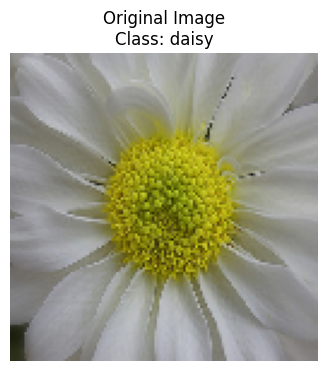

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step

Feature Map Shapes:

Layer 1: (1, 128, 128, 32)
Layer 2: (1, 64, 64, 64)
Layer 3: (1, 32, 32, 128)


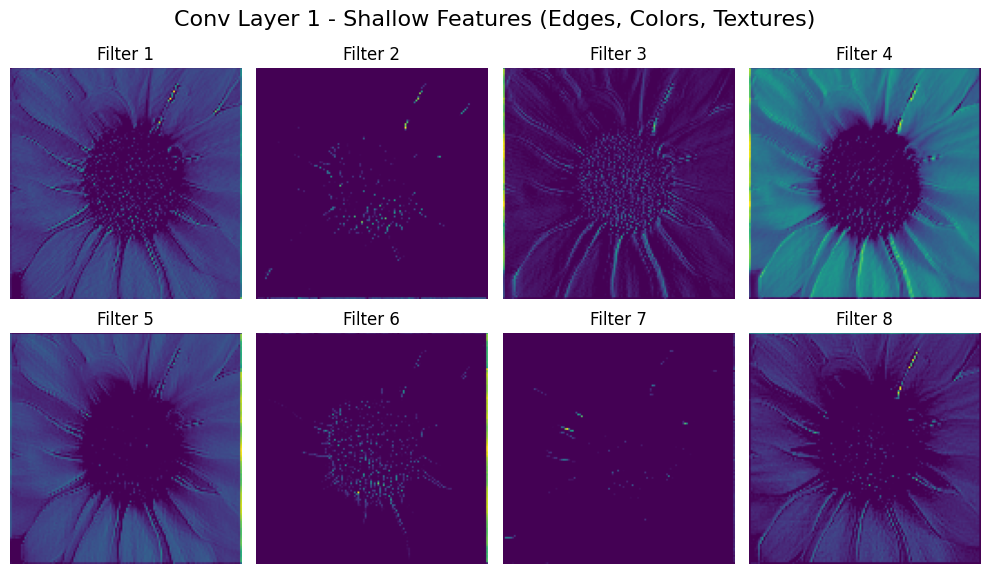

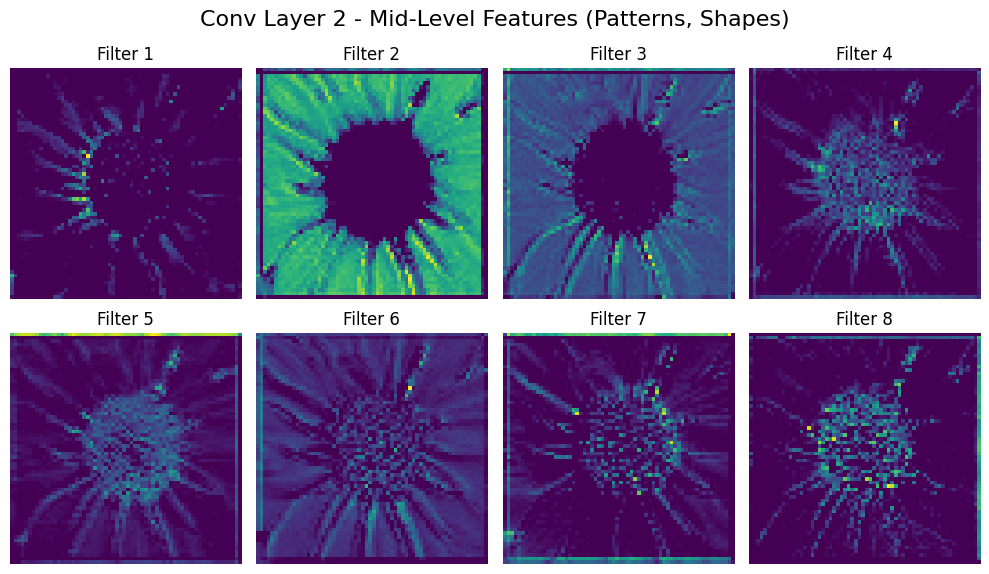

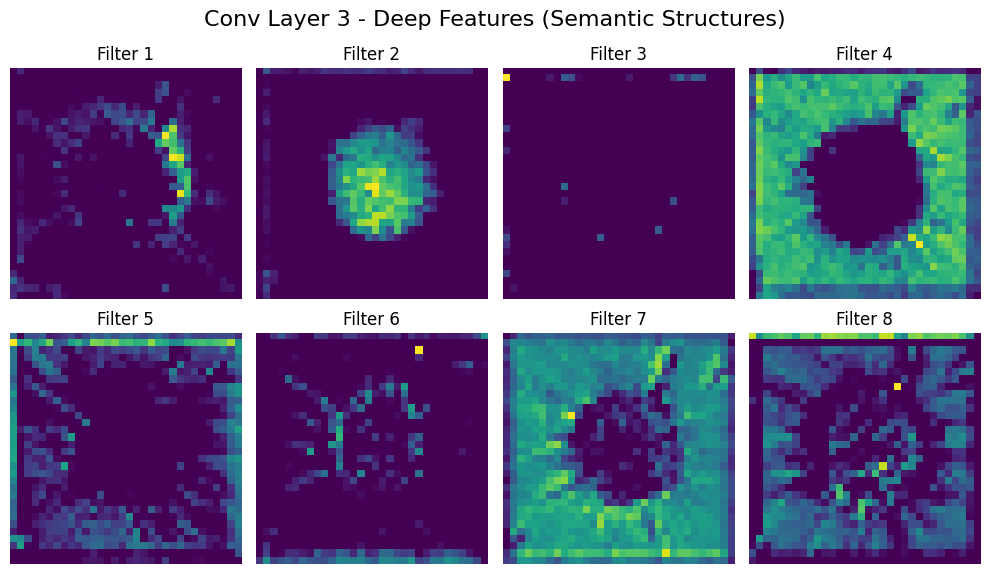

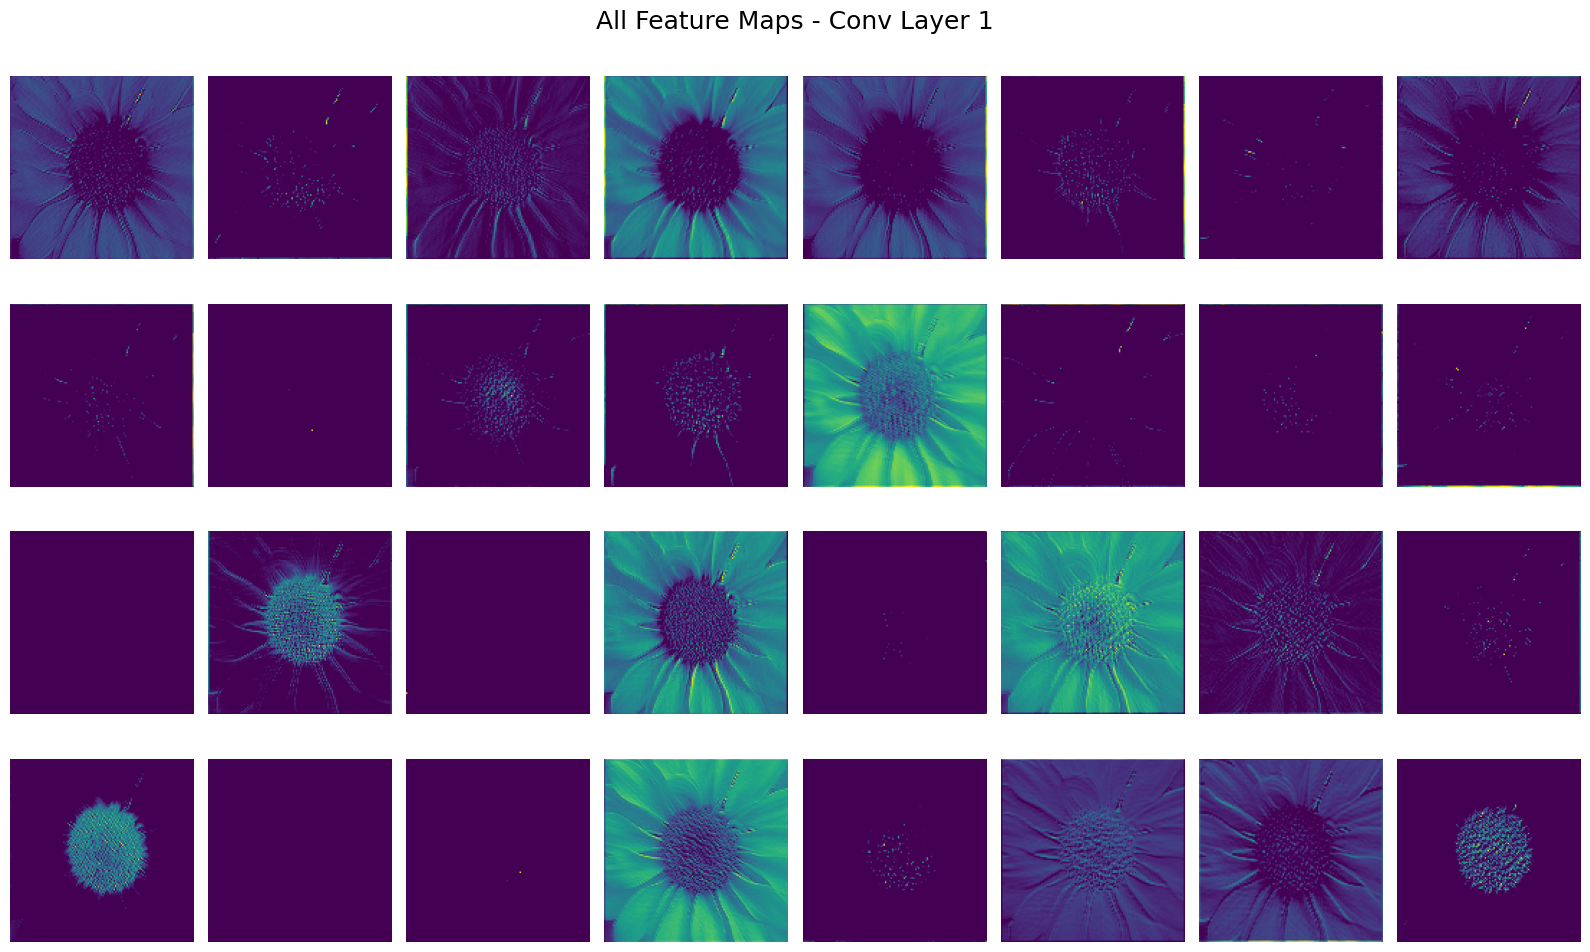


Feature Map Statistics

Layer 1
Shape : (1, 128, 128, 32)
Min   : 0.0000
Max   : 0.4728
Mean  : 0.0281
----------------------------------------
Layer 2
Shape : (1, 64, 64, 64)
Min   : 0.0000
Max   : 2.6649
Mean  : 0.1527
----------------------------------------
Layer 3
Shape : (1, 32, 32, 128)
Min   : 0.0000
Max   : 4.2916
Mean  : 0.2818
----------------------------------------


In [ ]:
# ======================================================
# 8. FEATURE MAP VISUALIZATION & CNN INTERPRETABILITY
# ======================================================

# ==============================
# 8.1 IMPORT REQUIRED LIBRARIES
# ==============================

from tensorflow.keras.models import Model

# ==============================
# 8.2 SELECT CONVOLUTION LAYERS
# ==============================

# Get all Conv2D layers
conv_layers = [

    layer for layer in model.layers

    if isinstance(layer, tf.keras.layers.Conv2D)
]

# Select first 3 convolution layers
selected_layers = conv_layers[:3]

print("Selected Convolution Layers:\n")

for i, layer in enumerate(selected_layers):

    print(f"Layer {i+1}: {layer.name}")

# ==============================
# 8.3 BUILD FEATURE EXTRACTION MODEL
# ==============================

feature_model = Model(

    inputs=model.inputs,

    outputs=[layer.output for layer in selected_layers]
)

# ==============================
# 8.4 LOAD SAMPLE IMAGE
# ==============================

# Get one validation batch
img_batch, label_batch = next(val_data)

# Select first image
img_sample = img_batch[0]

# Expand dimensions for CNN input
img_input = np.expand_dims(img_sample, axis=0)

print("\nInput Image Shape:")

print(img_input.shape)

# ==============================
# 8.5 DISPLAY ORIGINAL IMAGE
# ==============================

true_class = class_names[np.argmax(label_batch[0])]

plt.figure(figsize=(4,4))

plt.imshow(img_sample)

plt.title(f"Original Image\nClass: {true_class}")

plt.axis("off")

plt.show()

# ==============================
# 8.6 EXTRACT FEATURE MAPS
# ==============================

feature_maps = feature_model.predict(img_input)

print("\nFeature Map Shapes:\n")

for i, fmap in enumerate(feature_maps):

    print(f"Layer {i+1}: {fmap.shape}")

# ==============================
# 8.7 FEATURE MAP VISUALIZATION FUNCTION
# ==============================

def visualize_feature_maps(

    feature_map,

    layer_title,

    max_filters=8
):

    num_filters = feature_map.shape[-1]

    num_show = min(num_filters, max_filters)

    cols = 4

    rows = int(np.ceil(num_show / cols))

    plt.figure(figsize=(10,6))

    plt.suptitle(layer_title, fontsize=16)

    for i in range(num_show):

        plt.subplot(rows, cols, i + 1)

        plt.imshow(

            feature_map[0, :, :, i],

            cmap='viridis'
        )

        plt.title(f"Filter {i+1}")

        plt.axis("off")

    plt.tight_layout()

    plt.show()

# ==============================
# 8.8 SHALLOW FEATURES
# ==============================

visualize_feature_maps(

    feature_maps[0],

    "Conv Layer 1 - Shallow Features (Edges, Colors, Textures)"
)

# ==============================
# 8.9 MID-LEVEL FEATURES
# ==============================

visualize_feature_maps(

    feature_maps[1],

    "Conv Layer 2 - Mid-Level Features (Patterns, Shapes)"
)

# ==============================
# 8.10 DEEP FEATURES
# ==============================

visualize_feature_maps(

    feature_maps[2],

    "Conv Layer 3 - Deep Features (Semantic Structures)"
)

# ==============================
# 8.11 VISUALIZE ALL FILTERS OF FIRST LAYER
# ==============================

first_layer_feature_map = feature_maps[0]

num_filters = first_layer_feature_map.shape[-1]

cols = 8

rows = int(np.ceil(num_filters / cols))

plt.figure(figsize=(16,10))

plt.suptitle(

    "All Feature Maps - Conv Layer 1",

    fontsize=18
)

for i in range(num_filters):

    plt.subplot(rows, cols, i + 1)

    plt.imshow(

        first_layer_feature_map[0, :, :, i],

        cmap='viridis'
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# ==============================
# 8.12 FEATURE MAP STATISTICS
# ==============================

print("\nFeature Map Statistics\n")

for i, fmap in enumerate(feature_maps):

    print(f"Layer {i+1}")

    print(f"Shape : {fmap.shape}")

    print(f"Min   : {fmap.min():.4f}")

    print(f"Max   : {fmap.max():.4f}")

    print(f"Mean  : {fmap.mean():.4f}")

    print("-" * 40)

# 9. FINAL PERFORMANCE SUMMARY & EXPORT RESULTS

FINAL CNN MODEL PERFORMANCE
Accuracy  : 0.7070
Precision : 0.7182
Recall    : 0.7070
F1-Score  : 0.7057

Performance Summary Table

      Metric     Score
0   Accuracy  0.706977
1  Precision  0.718244
2     Recall  0.706977
3   F1-Score  0.705711


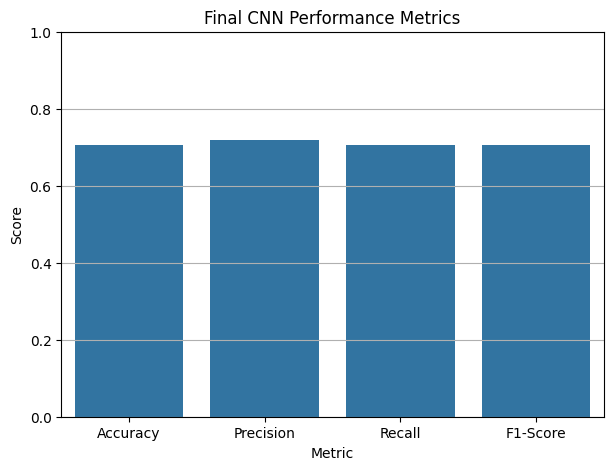


Performance summary exported successfully!
Classification report exported successfully!


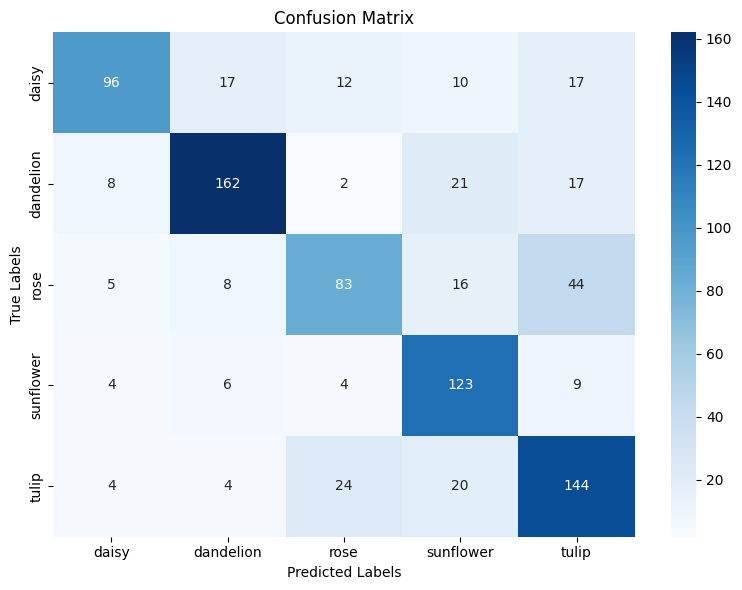

Confusion matrix figure saved successfully!

Training History Summary

Best Validation Accuracy : 0.7198
Best Validation Loss     : 0.8321

Overfitting Analysis

Training Accuracy  : 0.7640
Validation Accuracy: 0.7198
Accuracy Gap       : 0.0442

Model Generalization: GOOD

Final CNN model saved successfully!

CNN PIPELINE COMPLETED SUCCESSFULLY!

Generated Files:
- best_cnn_model.keras
- final_cnn_model.keras
- classification_report.csv
- cnn_performance_summary.csv
- confusion_matrix.png


In [ ]:
# ======================================================
# 9. FINAL PERFORMANCE SUMMARY & EXPORT RESULTS
# ======================================================

# ==============================
# 9.1 FINAL PERFORMANCE SUMMARY
# ==============================

print("=" * 50)

print("FINAL CNN MODEL PERFORMANCE")

print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

print("=" * 50)

# ==============================
# 9.2 CREATE SUMMARY DATAFRAME
# ==============================

summary_df = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"
    ],

    "Score": [

        accuracy,

        precision,

        recall,

        f1
    ]
})

print("\nPerformance Summary Table\n")

print(summary_df)

# ==============================
# 9.3 VISUALIZE FINAL METRICS
# ==============================

plt.figure(figsize=(7,5))

sns.barplot(

    data=summary_df,

    x="Metric",

    y="Score"
)

plt.ylim(0, 1)

plt.title("Final CNN Performance Metrics")

plt.ylabel("Score")

plt.grid(axis='y')

plt.show()

# ==============================
# 9.4 EXPORT PERFORMANCE SUMMARY
# ==============================

summary_df.to_csv(

    "cnn_performance_summary.csv",

    index=False
)

print("\nPerformance summary exported successfully!")

# ==============================
# 9.5 EXPORT CLASSIFICATION REPORT
# ==============================

classification_df = pd.DataFrame(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        output_dict=True
    )

).transpose()

classification_df.to_csv(

    "classification_report.csv"
)

print("Classification report exported successfully!")

# ==============================
# 9.6 SAVE CONFUSION MATRIX FIGURE
# ==============================

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.tight_layout()

plt.savefig(

    "confusion_matrix.png",

    dpi=300
)

plt.show()

print("Confusion matrix figure saved successfully!")

# ==============================
# 9.7 TRAINING HISTORY SUMMARY
# ==============================

best_val_acc = max(history.history['val_accuracy'])

best_val_loss = min(history.history['val_loss'])

print("\nTraining History Summary\n")

print(f"Best Validation Accuracy : {best_val_acc:.4f}")

print(f"Best Validation Loss     : {best_val_loss:.4f}")

# ==============================
# 9.8 OVERFITTING CHECK
# ==============================

final_train_acc = history.history['accuracy'][-1]

final_val_acc = history.history['val_accuracy'][-1]

gap = abs(final_train_acc - final_val_acc)

print("\nOverfitting Analysis\n")

print(f"Training Accuracy  : {final_train_acc:.4f}")

print(f"Validation Accuracy: {final_val_acc:.4f}")

print(f"Accuracy Gap       : {gap:.4f}")

if gap < 0.05:

    print("\nModel Generalization: GOOD")

elif gap < 0.10:

    print("\nModel Generalization: MODERATE OVERFITTING")

else:

    print("\nModel Generalization: HIGH OVERFITTING")

# ==============================
# 9.9 SAVE FINAL MODEL
# ==============================

model.save("final_cnn_model.keras")

print("\nFinal CNN model saved successfully!")

# ==============================
# 9.10 COMPLETE PIPELINE MESSAGE
# ==============================

print("\nCNN PIPELINE COMPLETED SUCCESSFULLY!")

print("\nGenerated Files:")

print("- best_cnn_model.keras")

print("- final_cnn_model.keras")

print("- classification_report.csv")

print("- cnn_performance_summary.csv")

print("- confusion_matrix.png")